🎨 STARTING FELZENSZWALB 2D AUDIO SEGMENTATION
🎵 LOADING AUDIO: ../thingies/clips/plainte2.mp3
   ⏱️  Duration: 53.04s, Sample Rate: 48000Hz
📊 COMPUTING STFT...
   🔧 n_fft=2048, hop_length=512
   📏 Spectrogram shape: 1025 freq × 4973 time
🎨 PREPARING IMAGE FOR SEGMENTATION...
   🖼️  Image range: 0-255 (8-bit grayscale)
🧩 RUNNING FELZENSZWALB SEGMENTATION...
   ⚙️  scale=150, sigma=3, min_size=20
   🎯 Found 647 initial segments (labels)
🔍 EXTRACTING 2D SHAPES (one per label)...
   🎵 rms: 0.02
   🎵 Shape  1: 1.51s ×  40bins, energy=4.5e-03 → felzen_shape_001_t143_f40.wav
   🎵 rms: 0.01
   🎵 Shape  2: 1.65s ×  59bins, energy=9.4e-03 → felzen_shape_002_t156_f59.wav
   🎵 rms: 0.01
   🎵 Shape  3: 7.21s × 124bins, energy=4.2e-02 → felzen_shape_003_t677_f124.wav
   🎵 rms: 0.01
   🎵 Shape  4: 0.96s ×  39bins, energy=2.6e-03 → felzen_shape_004_t91_f39.wav
   🎵 rms: 0.01
   🎵 Shape  5: 1.94s ×  41bins, energy=7.8e-03 → felzen_shape_005_t183_f41.wav
   🎵 rms: 0.02
   🎵 Shape  6: 1.56s ×  42bins, en

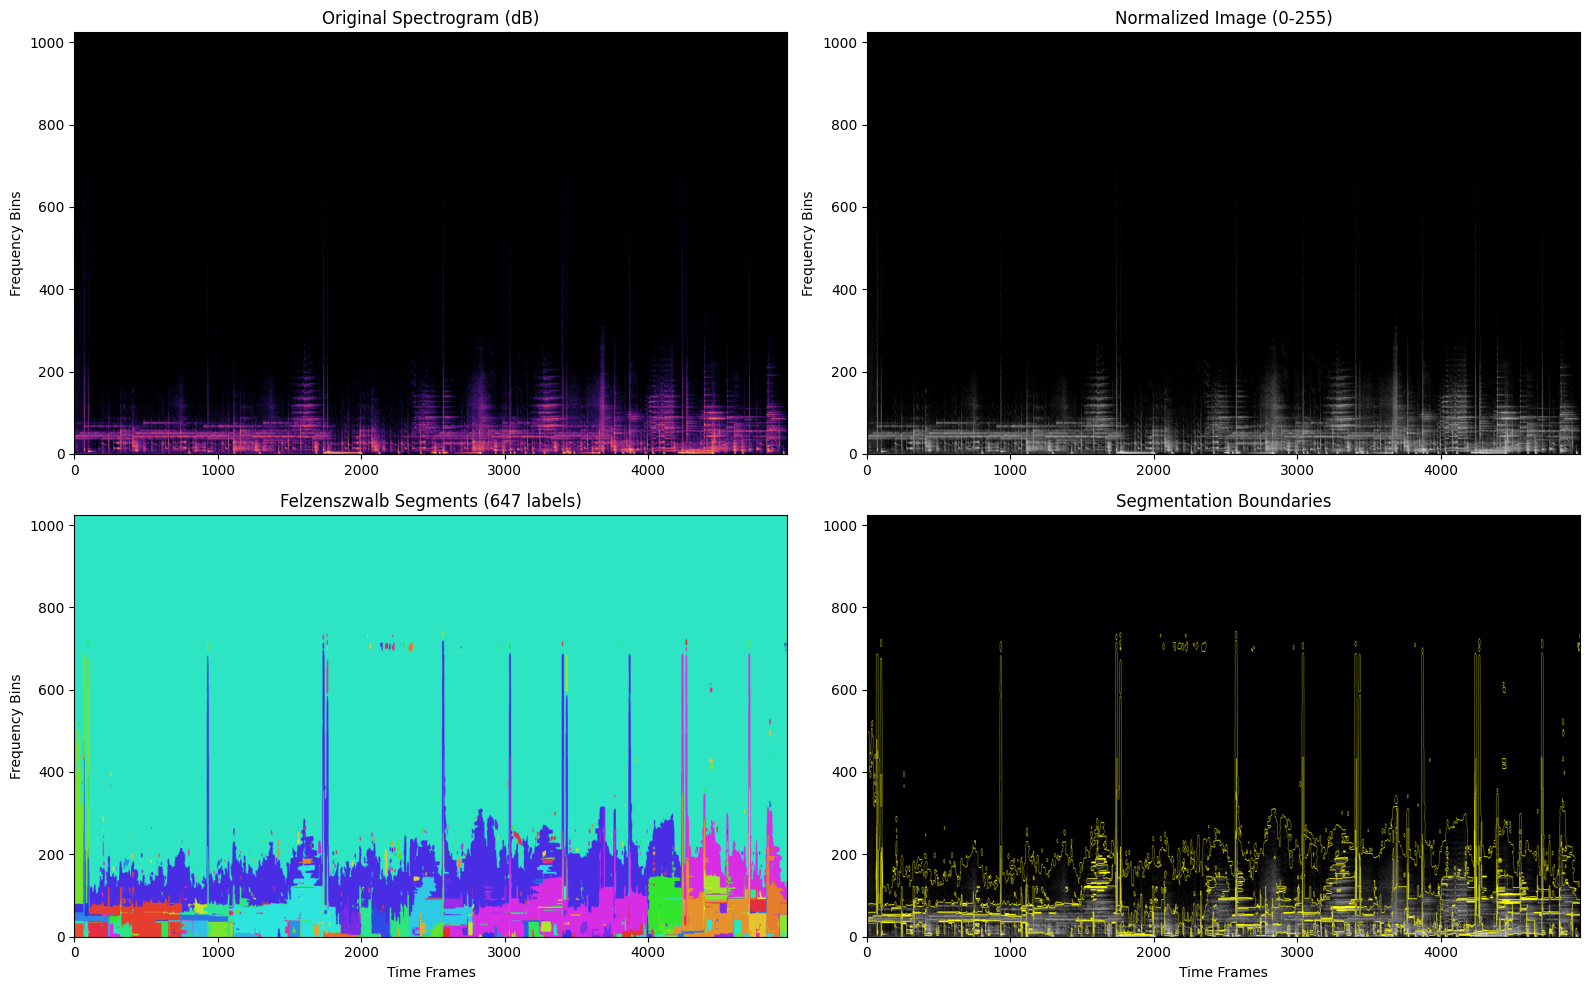


📊 SUMMARY:
   ⏱️  Processing time: 20.23s
   🧩 Total labels found: 647
   🧩 Label regions processed (kept + filtered): 647
   ❌ Filtered out: 596
      └─ By time (< 0.5s duration): 501
      └─ By time (empty): 0
      └─ By energy (< 1.0e-03 ratio): 95
      └─ By area (< 200 pixels): 0
   ✅ Audio chunks saved: 51
   📁 Output directory: chunks_detailed_plainte2/
   🎵 Average chunk duration: 2.67s


In [11]:
import numpy as np
import librosa
import soundfile as sf
import os
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb, mark_boundaries
from skimage.util import img_as_ubyte
import time

def split_audio_felzenszwalb_2d(
    audio_path,
    output_dir="chunks_detailed_{song_path.split('/')[-1].split('.')[0]}",
    n_fft=2048,
    hop_length=512,
    scale=150,
    sigma=3,
    min_size=20,
    min_area_pixels=200,
    min_time_seconds=0.1,
    min_energy_ratio=1e-4,
    max_shapes=None,
):
    """
    🎨 TRUE 2D FELZENSZWALB AUDIO SEGMENTATION (no connected-components)

    This function treats audio spectrograms like images and segments them into irregular 2D shapes.
    Unlike traditional time-based chunking, this extracts spectral "objects" from music.

    HOW IT WORKS:
    1) Compute STFT (frequency × time matrix)
    2) Treat magnitude spectrogram as a grayscale image
    3) Run Felzenszwalb segmentation to get label regions
    4) For EACH LABEL (as a whole), reconstruct its audio by masking the original STFT
    5) Save each label’s audio as its own file

    PARAMETERS:
    - n_fft: Frequency resolution (higher = more freq detail, less time detail)
    - hop_length: Time resolution (lower = more time detail, less freq detail)
    - scale/sigma/min_size: Felzenszwalb controls
    - min_area_pixels / min_time_seconds / min_energy_ratio: filters to skip tiny/short/quiet labels
    """
    start_time = time.time()
    os.makedirs(output_dir, exist_ok=True)

    print(f"🎵 LOADING AUDIO: {audio_path}")

    # 1) Load audio
    y, sr = librosa.load(audio_path, sr=None)
    duration = len(y) / sr
    print(f"   ⏱️  Duration: {duration:.2f}s, Sample Rate: {sr}Hz")

    # 2) Complex STFT and magnitude
    print(f"📊 COMPUTING STFT...")
    print(f"   🔧 n_fft={n_fft}, hop_length={hop_length}")
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window="hann", center=True)
    S = np.abs(D)  # (freq_bins, time_frames)
    freq_bins, time_frames = S.shape
    print(f"   📏 Spectrogram shape: {freq_bins} freq × {time_frames} time")

    # 3) Log scale + normalize to 0..255 for segmentation
    print(f"🎨 PREPARING IMAGE FOR SEGMENTATION...")
    S_db = librosa.amplitude_to_db(S + 1e-12, ref=np.max)
    S_db_norm = (S_db - S_db.min()) / max(1e-12, (S_db.max() - S_db.min()))
    img = img_as_ubyte(S_db_norm)  # 2D grayscale image
    print(f"   🖼️  Image range: {img.min()}-{img.max()} (8-bit grayscale)")

    # 4) Felzenszwalb segmentation on 2D spectrogram image
    print(f"🧩 RUNNING FELZENSZWALB SEGMENTATION...")
    print(f"   ⚙️  scale={scale}, sigma={sigma}, min_size={min_size}")
    segments = felzenszwalb(img, scale=scale, sigma=sigma, min_size=min_size)
    unique_labels = np.unique(segments)
    print(f"   🎯 Found {len(unique_labels)} initial segments (labels)")

    # 5) Process each label as a single region (no CC)
    print(f"🔍 EXTRACTING 2D SHAPES (one per label)...")
    total_energy = float(S.sum()) + 1e-12
    T = S.shape[1]
    times = librosa.frames_to_time(np.arange(T), sr=sr, hop_length=hop_length)

    saved_paths = []
    shape_index = 0
    filtered_shapes = 0
    filtered_by_area = 0
    filtered_by_energy = 0
    filtered_by_time = 0
    filtered_by_time_empty = 0
    kept_segments = []

    for _, label in enumerate(unique_labels):
        chunk_mask = (segments == label)          # use the label mask directly

        # Filter 1: Time span too short
        time_mask = np.any(chunk_mask, axis=0)
        min_time_frames = int(min_time_seconds * sr / hop_length)
        if time_mask.sum() < min_time_frames:
            filtered_shapes += 1
            filtered_by_time += 1
            continue

        # Filter 2: Energy too low
        energy = float(S[chunk_mask].sum())
        energy_ratio = energy / total_energy
        if energy_ratio < min_energy_ratio:
            filtered_shapes += 1
            filtered_by_energy += 1
            continue

        # Filter 3: Area too small  
        area = int(chunk_mask.sum())
        if area < min_area_pixels:
            filtered_shapes += 1
            filtered_by_area += 1
            continue

        # Calculate shape boundaries
        t0 = int(np.argmax(time_mask))
        t1 = int(len(time_mask) - np.argmax(time_mask[::-1]) - 1)
        freq_mask = np.any(chunk_mask, axis=1)
        f0 = int(np.argmax(freq_mask))
        f1 = int(len(freq_mask) - np.argmax(freq_mask[::-1]) - 1)

        time_span = times[t1] - times[t0] if t1 > t0 else 0
        freq_span = f1 - f0 + 1

        # 🎵 RECONSTRUCT AUDIO: Mask the complex STFT with this label region
        D_masked = D * chunk_mask.astype(D.dtype)
        y_rec = librosa.istft(D_masked, hop_length=hop_length, length=len(y))

        # Slice to the time span of this shape for a concise chunk
        start_samp = int(times[t0] * sr)
        end_samp = min(len(y), int(times[min(t1 + 1, T - 1)] * sr))
        y_seg = y_rec[start_samp:end_samp]
        if y_seg.size == 0:
            filtered_shapes += 1
            filtered_by_time_empty += 1
            continue

        # # # Normalize to avoid clipping
        # peak = np.max(np.abs(y_seg))
        # if peak > 0:
        #     y_seg = 0.98 * y_seg / peak

        # Simple RMS loudness normalization
        # target_rms = 0.1  # target average amplitude (~-20 dBFS, adjust as needed)
        # rms = np.sqrt(np.mean(y_seg**2) + 1e-12)
        # if rms > 0:
        #     y_seg = y_seg * (target_rms / rms)
        
        # Normalize to avoid clipping
        peak = np.max(np.abs(y_seg))      
        if peak > 1.0: 
            y_seg = 0.98 * y_seg / peak
        
        shape_index += 1
        filename = f"felzen_shape_{shape_index:03d}_t{(t1 - t0 + 1)}_f{freq_span}.wav"
        out_path = os.path.join(output_dir, filename)
        sf.write(out_path, y_seg, sr)
        saved_paths.append(out_path)
        print(f"   🎵 rms: {np.sqrt(np.mean(y_seg**2)):.2f}")

        kept_segments.append({
            "idx": int(shape_index - 1),
            "label": int(label),
            "t0_frame": int(t0),
            "t1_frame": int(t1),
            "t0_sec": float(times[t0]),
            "t1_sec": float(times[min(t1 + 1, T - 1)]),
            "f0_bin": int(f0),
            "f1_bin": int(f1),
            "freq_span": int(freq_span),
            "time_span_sec": float(time_span),
            "energy_ratio": float(energy_ratio),
            "path": out_path,
        })

        print(f"   🎵 Shape {shape_index:2d}: {time_span:.2f}s × {freq_span:3d}bins, energy={energy_ratio:.1e} → {filename}")

        if max_shapes is not None and shape_index >= max_shapes:
            break

    # 6) Create and display visualization
    print(f"📊 CREATING VISUALIZATIONS...")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Original spectrogram
    axes[0,0].imshow(S_db, aspect='auto', origin='lower', cmap='magma')
    axes[0,0].set_title('Original Spectrogram (dB)')
    axes[0,0].set_ylabel('Frequency Bins')

    # Normalized image for segmentation
    axes[0,1].imshow(img, aspect='auto', origin='lower', cmap='gray')
    axes[0,1].set_title('Normalized Image (0-255)')
    axes[0,1].set_ylabel('Frequency Bins')

    from matplotlib.colors import ListedColormap, hsv_to_rgb
    n_labels = len(unique_labels)
    hsv_colors = [(i / n_labels, 0.8, 0.9) for i in range(n_labels)]
    rgb_colors = [hsv_to_rgb(c) for c in hsv_colors]
    np.random.shuffle(rgb_colors)  # shuffle to avoid adjacent similar colors
    unique_cmap = ListedColormap(rgb_colors)
    axes[1,0].imshow(segments, aspect='auto', origin='lower', cmap=unique_cmap)
    # # Segmentation labels
    # axes[1,0].imshow(segments, aspect='auto', origin='lower', cmap='tab20')
    axes[1,0].set_title(f'Felzenszwalb Segments ({len(unique_labels)} labels)')
    axes[1,0].set_xlabel('Time Frames')
    axes[1,0].set_ylabel('Frequency Bins')

    # Boundaries overlay
    boundary_img = mark_boundaries(np.dstack([S_db_norm]*3), segments)
    axes[1,1].imshow(boundary_img, aspect='auto', origin='lower')
    axes[1,1].set_title('Segmentation Boundaries')
    axes[1,1].set_xlabel('Time Frames')

    plt.tight_layout()
    viz_path = os.path.join(output_dir, "felzenszwalb_analysis.png")
    plt.savefig(viz_path, dpi=160, bbox_inches='tight')
    print(f"   💾 Saved visualization: {viz_path}")
    plt.show()

    # Summary statistics
    total_time = time.time() - start_time
    print(f"\n📊 SUMMARY:")
    print(f"   ⏱️  Processing time: {total_time:.2f}s")
    print(f"   🧩 Total labels found: {len(unique_labels)}")
    print(f"   🧩 Label regions processed (kept + filtered): {shape_index + filtered_shapes}")
    print(f"   ❌ Filtered out: {filtered_shapes}")
    print(f"      └─ By time (< {min_time_seconds}s duration): {filtered_by_time}")
    print(f"      └─ By time (empty): {filtered_by_time_empty}")
    print(f"      └─ By energy (< {min_energy_ratio:.1e} ratio): {filtered_by_energy}")
    print(f"      └─ By area (< {min_area_pixels} pixels): {filtered_by_area}")
    print(f"   ✅ Audio chunks saved: {shape_index}")
    print(f"   📁 Output directory: {output_dir}/")
    if saved_paths:
        print(f"   🎵 Average chunk duration: {np.mean([len(sf.read(p)[0])/sr for p in saved_paths[:5]]):.2f}s")
    else:
        print(f"   🎵 Average chunk duration: n/a")

    return saved_paths, kept_segments

# 🚀 RUN THE SEGMENTATION
print("🎨 STARTING FELZENSZWALB 2D AUDIO SEGMENTATION")
print("=" * 60)
song_path = "../thingies/clips/plainte2.mp3"
shapes, kept_segments = split_audio_felzenszwalb_2d(
    song_path,
    output_dir=f"chunks_detailed_{song_path.split('/')[-1].split('.')[0]}",
    scale=150,      # Lower = more segments
    sigma=3,        # Lower = sharper boundaries
    min_size=20,    # Larger = fewer tiny segments
    max_shapes=100,  # Limit output for testing
    min_area_pixels=200,
    min_time_seconds=0.5,  # Minimum duration in seconds
    min_energy_ratio=1e-3
)

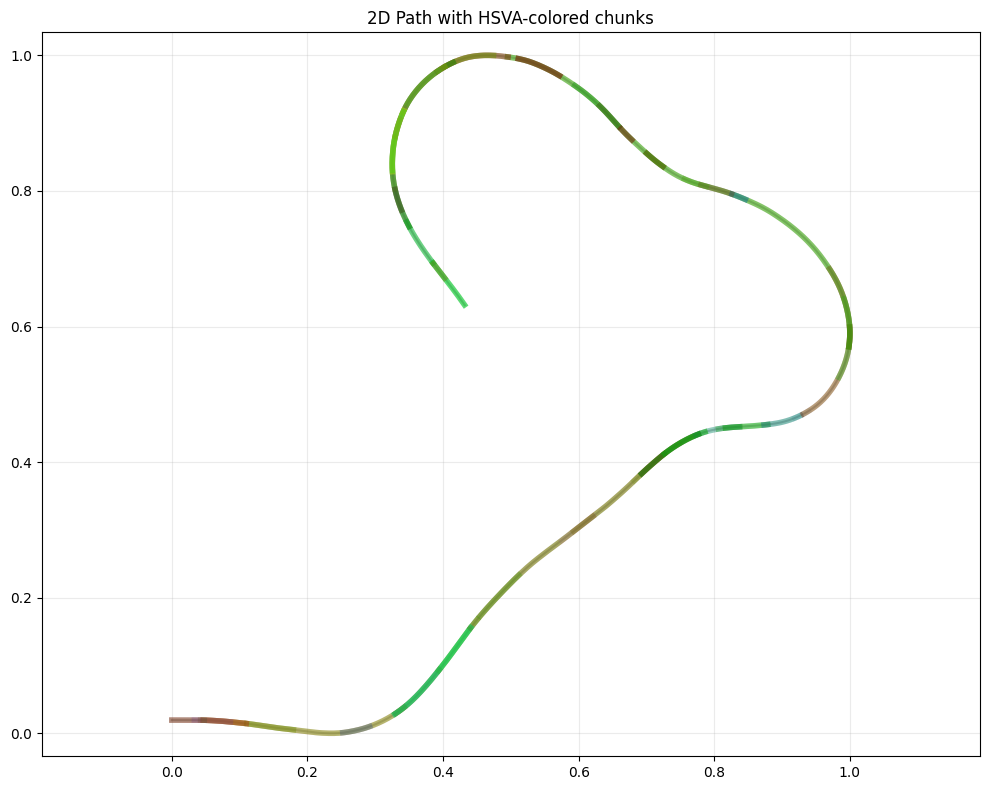

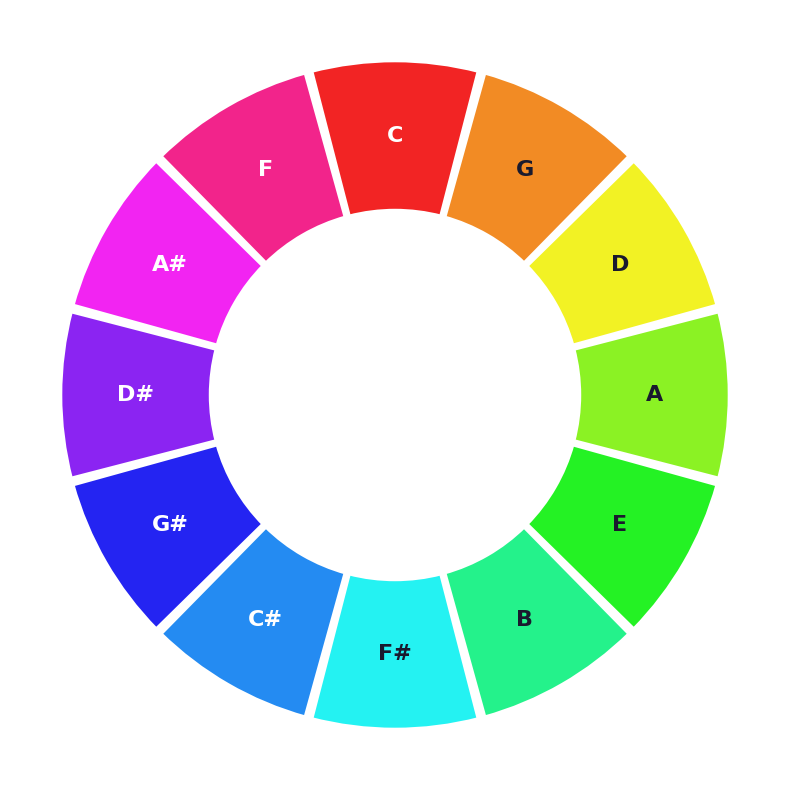

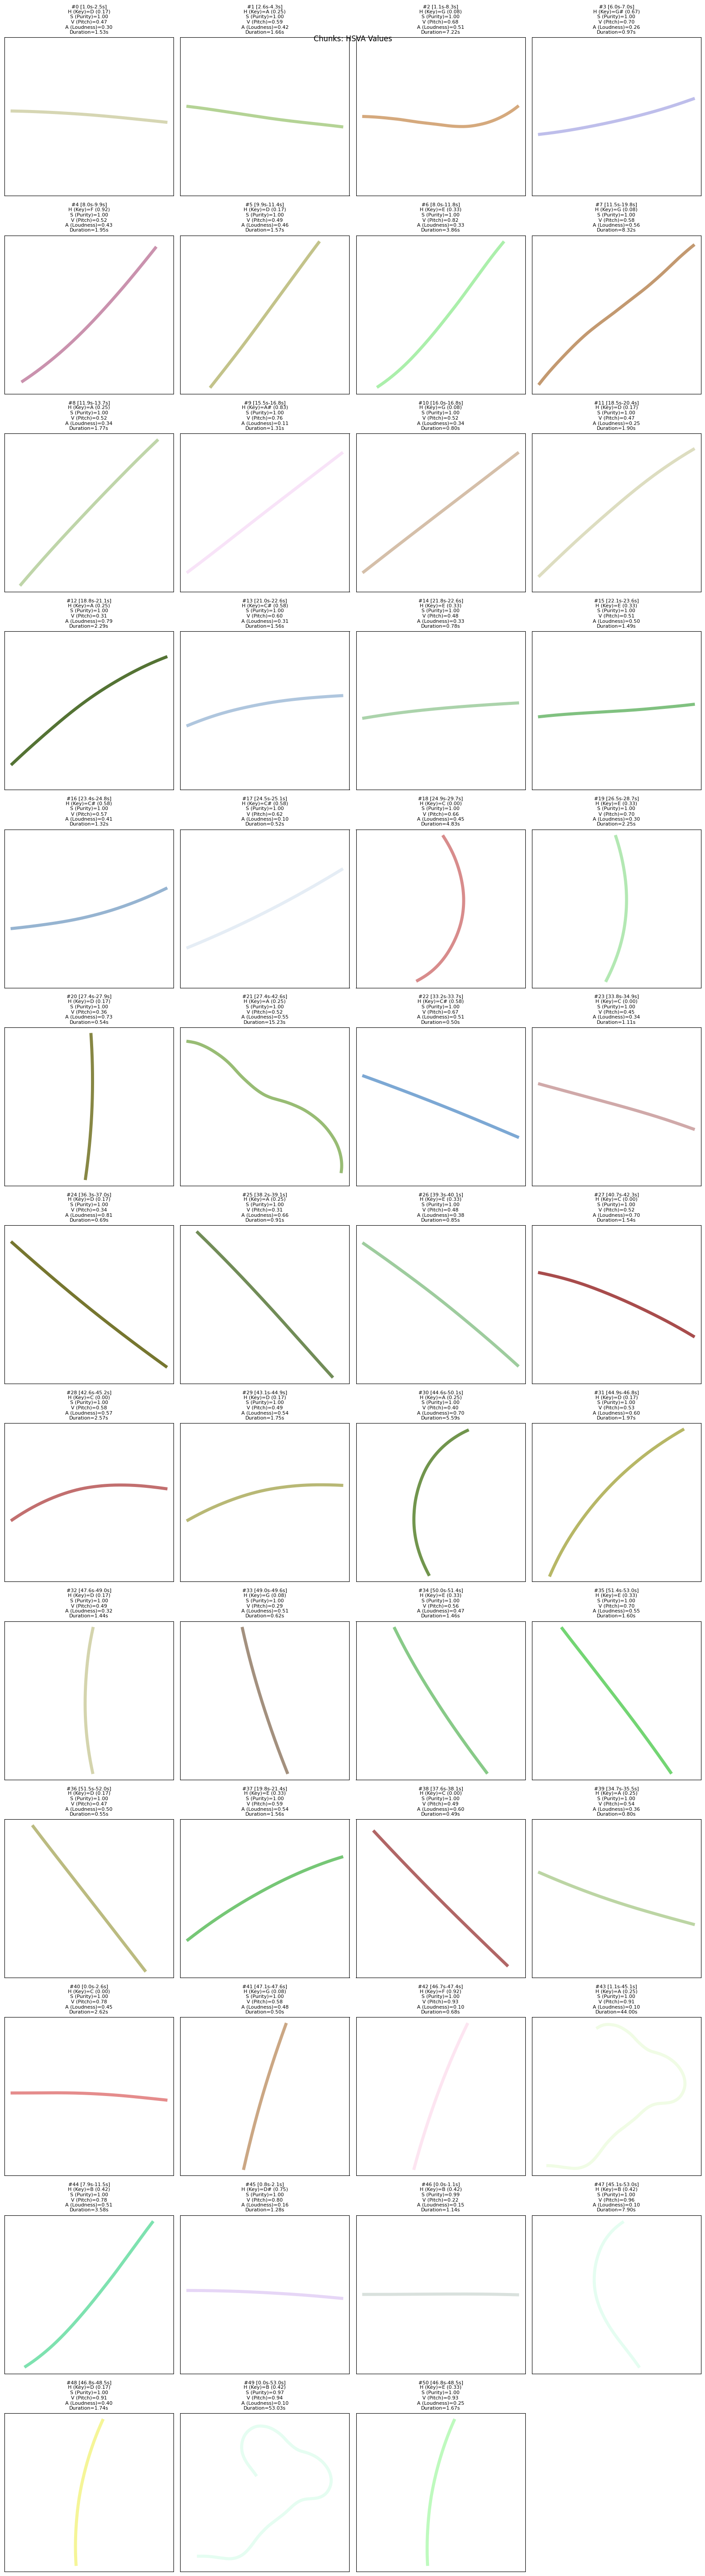

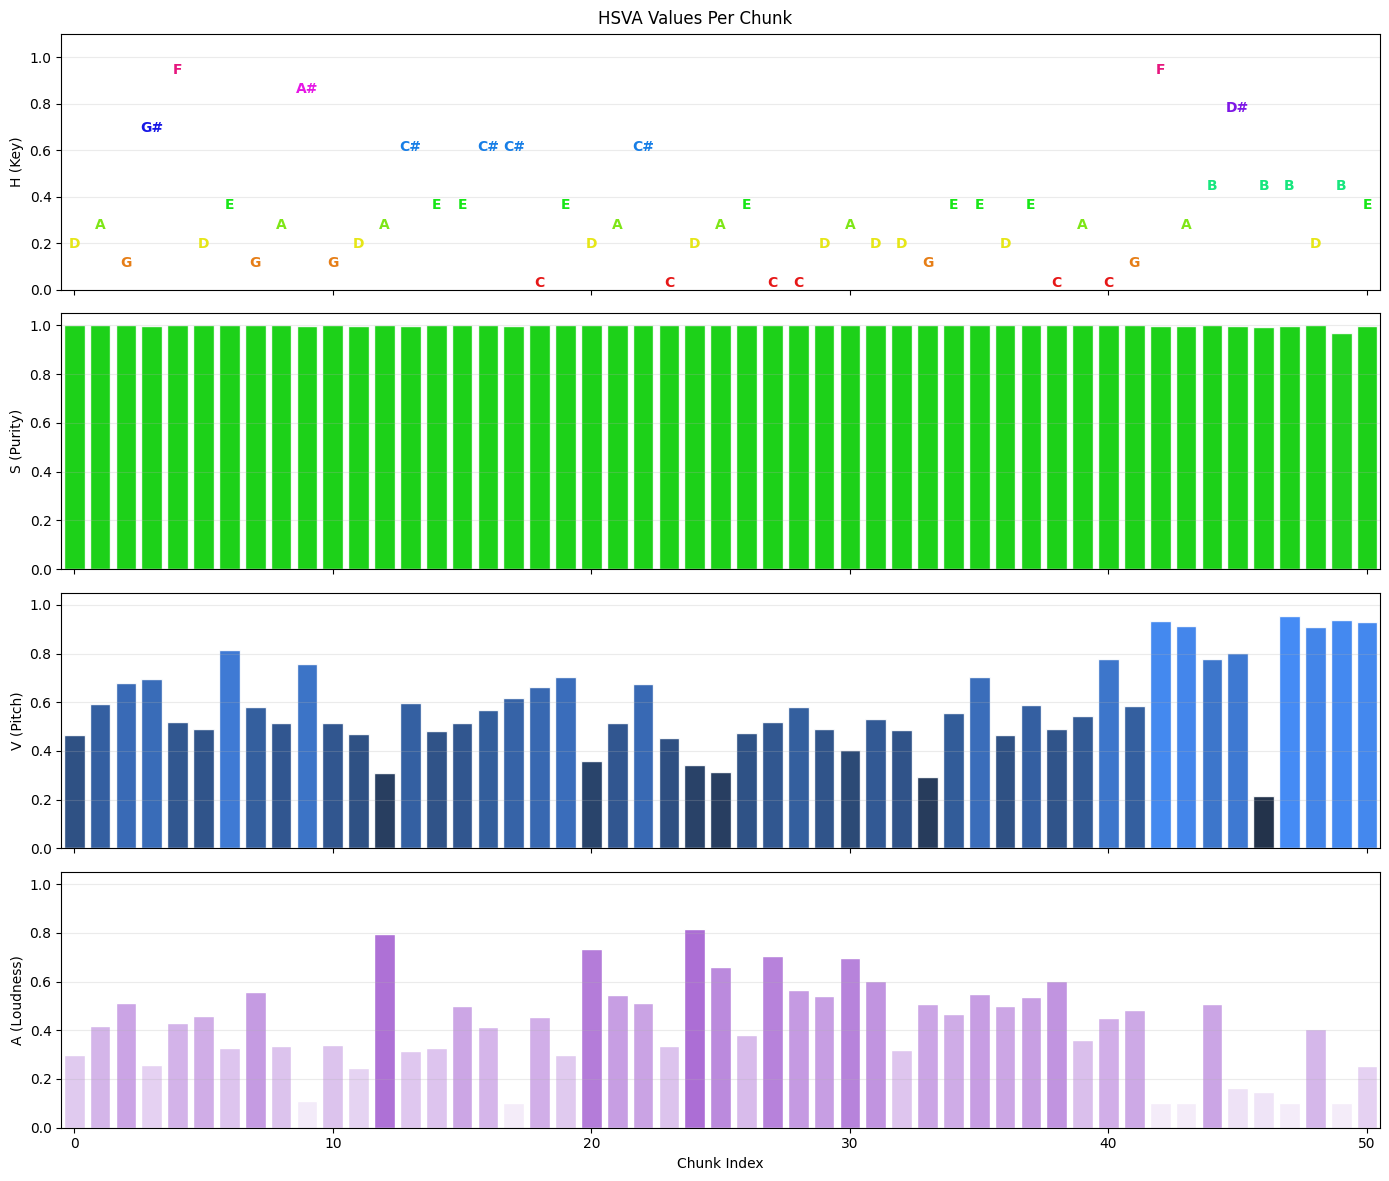

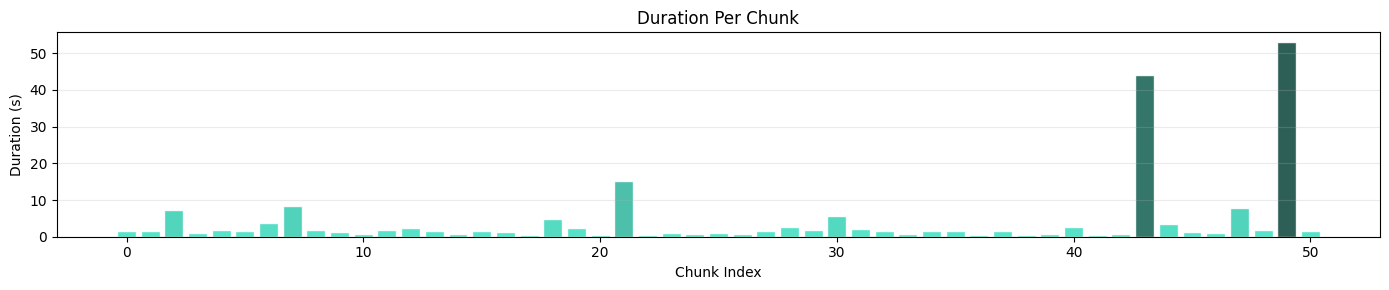


📊 Summary (51 chunks):
   H (Key):      0.30
   S (Purity):   1.00
   V (Pitch):    0.59
   A (Loudness): 0.42
   Duration:     4.08s total=207.86s


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys
import sys
sys.path.insert(0, '..')

from utils.sound_utils import create_2d_path_visualization
from matplotlib.patches import Wedge
import soundfile as sf

# Circle of fifths for key names
CIRCLE_ORDER = [0, 7, 2, 9, 4, 11, 6, 1, 8, 3, 10, 5]
PITCH_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

def hue_to_key_name(h):
    idx = int(h * 12) % 12
    pitch_idx = CIRCLE_ORDER[idx]
    return PITCH_NAMES[pitch_idx]

# Run visualization
X, Y, curve_chunks_2d, curve_profiles_2d = create_2d_path_visualization(
    kept_segments,
    song_path,
    points_per_second=100,
    resampled_points_per_chunk=128,
    show_plots=False
)

for i, chunk in enumerate(curve_chunks_2d):
    seg = kept_segments[i]
    chunk["duration"] = seg["t1_sec"] - seg["t0_sec"]

overlay_idxs = list(range(min(100, len(curve_chunks_2d))))

# Figure 1: Full path
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
ax1.plot(X, Y, color="#333", linewidth=1.5, alpha=0.3)
for i in overlay_idxs:
    chunk = curve_chunks_2d[i]
    ax1.plot(chunk["x"], chunk["y"], linewidth=4.0, color=chunk["color_rgba"])
ax1.set_title("2D Path with HSVA-colored chunks")
ax1.axis('equal')
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Figure 2: Circle of fifths
fig_cof, ax_cof = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFFFFF')
ax_cof.set_facecolor('#FFFFFF')

R_outer, R_inner = 1.0, 0.55

for k in range(12):
    pitch = CIRCLE_ORDER[k]
    H = k / 12.0
    r_col, g_col, b_col = colorsys.hsv_to_rgb(H, 0.85, 0.95)

    theta_center = 90.0 - k * 30.0
    theta1, theta2 = theta_center - 14.5, theta_center + 14.5

    # Wedge
    wedge = Wedge((0, 0), R_outer, theta1, theta2, width=R_outer - R_inner,
                facecolor=(r_col, g_col, b_col), edgecolor='#FFFFFF', linewidth=3)
    ax_cof.add_patch(wedge)

    # Letter inside wedge
    theta_mid = np.deg2rad(theta_center)
    r_text = (R_outer + R_inner) / 2
    tx, ty = r_text * np.cos(theta_mid), r_text * np.sin(theta_mid)

    brightness = 0.299 * r_col + 0.587 * g_col + 0.114 * b_col
    text_color = '#1a1a2e' if brightness > 0.6 else 'white'

    ax_cof.text(tx, ty, PITCH_NAMES[pitch], ha='center', va='center',
                fontsize=16, fontweight='bold', color=text_color)


ax_cof.set_xlim(-1.15, 1.15)
ax_cof.set_ylim(-1.15, 1.15)
ax_cof.set_aspect('equal')
ax_cof.axis('off')
plt.tight_layout()
plt.show()


# Figure 3: Grid with HSVA labels
N = len(overlay_idxs)
if N > 0:
    cols = 4
    rows = int(np.ceil(N / cols))
    fig2, axes2 = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4.5))
    axes2 = np.atleast_2d(axes2).reshape(rows, cols)

    for idx in range(rows * cols):
        r = idx // cols
        c = idx % cols
        ax = axes2[r, c]

        if idx < N:
            k = overlay_idxs[idx]
            chunk = curve_chunks_2d[k]
            rgba = chunk["color_rgba"]
            r_val, g_val, b_val, a_val = rgba
            h, s, v = colorsys.rgb_to_hsv(r_val, g_val, b_val)
            key_name = hue_to_key_name(h)

            ax.plot(chunk["x_resampled"], chunk["y_resampled"], color=rgba, linewidth=5.0)

            title = (
                f"#{k} [{chunk['t_start']:.1f}s-{chunk['t_end']:.1f}s]\n"
                f"H (Key)={key_name} ({h:.2f})\n"
                f"S (Purity)={s:.2f}\n"
                f"V (Pitch)={v:.2f}\n"
                f"A (Loudness)={a_val:.2f}\n"
                f"Duration={chunk['duration']:.2f}s"
            )
            ax.set_title(title, fontsize=8, linespacing=1.2)
            ax.axis('equal')
            ax.grid(True, alpha=0.25)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.axis('off')

    fig2.suptitle("Chunks: HSVA Values", fontsize=12)
    plt.tight_layout()
    plt.show()

# Collect HSVA data
chunk_ids = list(range(len(curve_chunks_2d)))
hsva_data = []
key_names_list = []
for chunk in curve_chunks_2d:
    r_val, g_val, b_val, a_val = chunk["color_rgba"]
    h, s, v = colorsys.rgb_to_hsv(r_val, g_val, b_val)
    hsva_data.append((h, s, v, a_val))
    key_names_list.append(hue_to_key_name(h))
hsva_data = np.array(hsva_data)

# Figure 4: HSVA per chunk
fig3, axes3 = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Hue - colored key letters
ax_h = axes3[0]
for j, (h_val, key) in enumerate(zip(hsva_data[:, 0], key_names_list)):
    color = colorsys.hsv_to_rgb(h_val, 0.9, 0.9)
    ax_h.text(j, h_val, key, ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)
ax_h.set_xlim(-0.5, len(chunk_ids) - 0.5)
ax_h.set_ylim(0, 1.1)
ax_h.set_ylabel('H (Key)')
ax_h.grid(True, alpha=0.25, axis='y')

# Saturation - gray to green
sat_colors = [colorsys.hsv_to_rgb(0.33, s, 0.8) for s in hsva_data[:, 1]]
axes3[1].bar(chunk_ids, hsva_data[:, 1], color=sat_colors, edgecolor='white', alpha=0.9)
axes3[1].set_ylabel('S (Purity)')
axes3[1].set_ylim(0, 1.05)
axes3[1].grid(True, alpha=0.25, axis='y')

# Value - dark to bright blue
val_colors = [colorsys.hsv_to_rgb(0.6, 0.8, v) for v in hsva_data[:, 2]]
axes3[2].bar(chunk_ids, hsva_data[:, 2], color=val_colors, edgecolor='white', alpha=0.9)
axes3[2].set_ylabel('V (Pitch)')
axes3[2].set_ylim(0, 1.05)
axes3[2].grid(True, alpha=0.25, axis='y')

# Alpha - transparent to opaque purple
alpha_colors = [(0.6, 0.3, 0.8, a) for a in hsva_data[:, 3]]
axes3[3].bar(chunk_ids, hsva_data[:, 3], color=alpha_colors, edgecolor='white')
axes3[3].set_ylabel('A (Loudness)')
axes3[3].set_ylim(0, 1.05)
axes3[3].set_xlabel('Chunk Index')
axes3[3].grid(True, alpha=0.25, axis='y')

fig3.suptitle("HSVA Values Per Chunk", fontsize=12)
plt.tight_layout()
plt.show()

# Figure 5: Duration - dark if high
fig4, ax4 = plt.subplots(figsize=(14, 3))
durations = [chunk["duration"] for chunk in curve_chunks_2d]
max_dur = max(durations)
dur_colors = [colorsys.hsv_to_rgb(0.47, 0.7, 0.9 - 0.6 * (d / max_dur)) for d in durations]  # dark if high
ax4.bar(chunk_ids, durations, color=dur_colors, edgecolor='white', alpha=0.9)
ax4.set_ylabel('Duration (s)')
ax4.set_xlabel('Chunk Index')
ax4.grid(True, alpha=0.25, axis='y')
ax4.set_title("Duration Per Chunk")
plt.tight_layout()
plt.show()

print(f"\n📊 Summary ({len(curve_chunks_2d)} chunks):")
print(f"   H (Key):      {np.mean(hsva_data[:,0]):.2f}")
print(f"   S (Purity):   {np.mean(hsva_data[:,1]):.2f}")
print(f"   V (Pitch):    {np.mean(hsva_data[:,2]):.2f}")
print(f"   A (Loudness): {np.mean(hsva_data[:,3]):.2f}")
print(f"   Duration:     {np.mean(durations):.2f}s total={sum(durations):.2f}s")